In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import scipy.stats as stats
from scipy.stats import skew, kurtosis, anderson, shapiro


In [3]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [5]:
df.shape

(120000, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [6]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      120000 non-null  object        
 1   transaction_date    120000 non-null  datetime64[ns]
 2   customer_id         120000 non-null  object        
 3   customer_gender     120000 non-null  object        
 4   customer_age_group  120000 non-null  object        
 5   customer_segment    120000 non-null  object        
 6   product_id          120000 non-null  object        
 7   product_name        120000 non-null  object        
 8   category            120000 non-null  object        
 9   brand               120000 non-null  object        
 10  quantity            120000 non-null  int64         
 11  unit_price          120000 non-null  float64       
 12  discount_pct        120000 non-null  int64         
 13  sales_amount        120000 no

In [7]:
df.isnull().sum()

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

##### 1. Dataset have 120,000 rows and 17 columns<br>2. transaction_date need to convert to datetime format<br>3. there is no missing value and duplicate row and columns in the dataset<br>4. columns need to drop because give nothing information = transaction_id, transaction_date, customer_id & product_id

In [9]:
df1 = df.copy()
df1.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [31]:
df1.describe(include='all')

,transaction_id,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000,120000,120000
unique,120000,24784,3,5,4,120,40,8,3,NaN,NaN,NaN,NaN,5,3,5
top,T0000001,C014343,Female,35-44,VIP,P1016,Dumbbells,Sports,Brand 1,NaN,NaN,NaN,NaN,Credit Card,Mobile App,Central
freq,1,15,40268,24196,30115,1096,3108,15218,40240,NaN,NaN,NaN,NaN,24262,40204,24244
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.662908,240.621785,5.496500,377.975454,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014291,146.457057,8.193257,356.893357,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,7.730000,0.000000,5.410000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,102.010000,0.000000,136.860000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,238.750000,0.000000,295.980000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,379.000000,10.000000,461.500000,NaN,NaN,NaN


##### Mostly customer are female from age 35-44 and Comes from central<br>Most of them bought Dumbells from Brand 1<br>They are likely using Credit Card and Mobile App to buy

In [32]:
df1.drop(columns=['transaction_id', 'customer_id', 'product_id'], inplace=True)
df1.head()

,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,Other,35-44,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,Other,45-54,New,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,Male,55+,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,Male,25-34,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,Male,45-54,New,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [20]:
num_col = df1.select_dtypes(include=np.number).columns
num_col.shape


(4,)

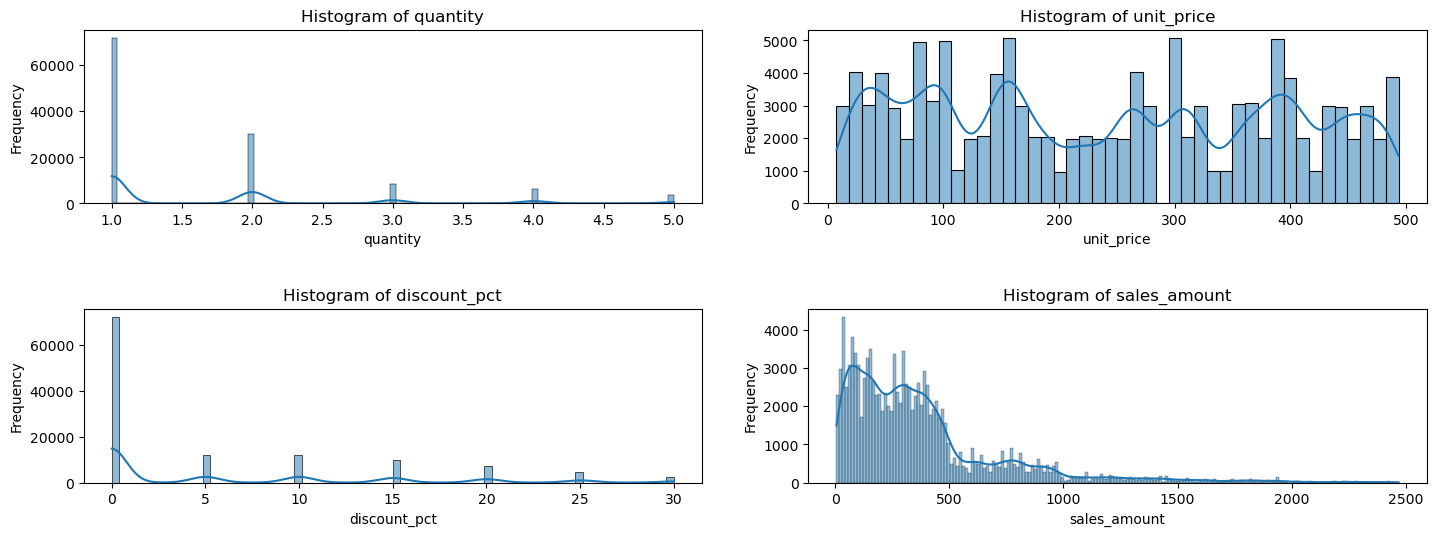

In [33]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(num_col,1):
    plt.subplot(2, 2, i)
    sns.histplot(df1[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout(pad=3)
plt.show()

In [34]:
df1.columns

Index(['customer_gender', 'customer_age_group', 'customer_segment',
       'product_name', 'category', 'brand', 'quantity', 'unit_price',
       'discount_pct', 'sales_amount', 'payment_method', 'sales_channel',
       'region'],
      dtype='object')

In [35]:
df1[num_col].skew().sort_values(ascending=False)

sales_amount    2.075947
quantity        1.692241
discount_pct    1.365003
unit_price      0.087601
dtype: float64

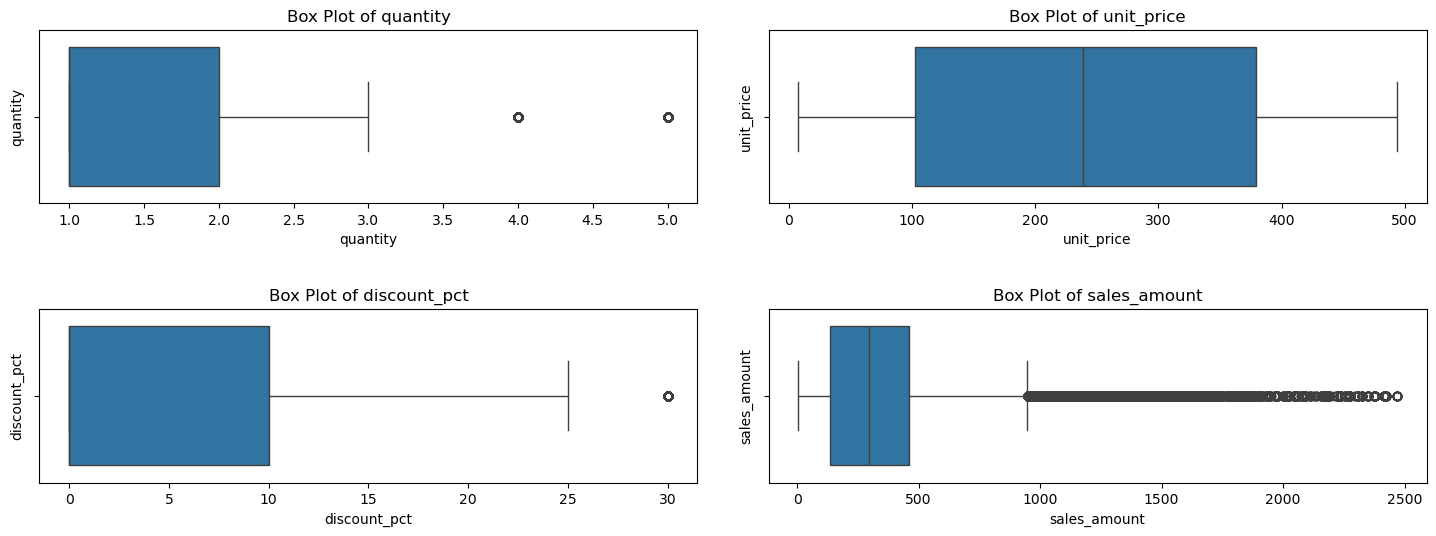

In [37]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(num_col,1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df1[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout(pad=3)
plt.show()

In [ ]:
q3, q1 = df1['sales_amount'].quantile([0.75, 0.25])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower Bound: {lower_bound}")
print(f"Number of outliers below lower bound: {len(df1[df1['sales_amount'] < lower_bound])}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of outliers above upper bound: {len(df1[df1['sales_amount'] > upper_bound])}")
print(f"Number of outliers in percentage: {((len(df1[df1['sales_amount'] < lower_bound]) + len(df1[df1['sales_amount'] > upper_bound])) / len(df1)) * 100:.2f}%")

Lower Bound: -350.09999999999997
Number of outliers below lower bound: 0
Upper Bound: 948.46
Number of outliers above upper bound: 8309
Number of outliers in percentage: 6.92%


##### 1. based on the histogram, there are discrete data for quantity, discount_pct column and unit_price<br>2. There are right-skew pattern these two histogram. they shows mostly customer bought 1 quantity without any discount/promotion<br>3. unit_price almost balance pattern<br>4. there are highly right-skew for sales_amount. Need to treat this skew and outlier

In [46]:
df1.drop(columns='sales_amount_log', inplace=True)
df1['sales_amount_log'] = np.log1p(df1['sales_amount'])

<Axes: xlabel='sales_amount_log', ylabel='Count'>

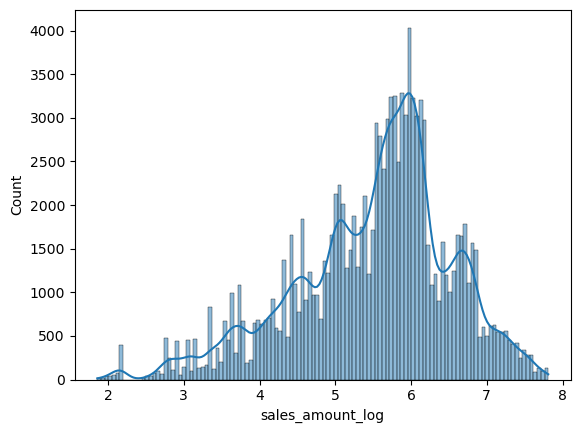

In [47]:
sns.histplot(df1['sales_amount_log'], kde=True)

<Axes: xlabel='sales_amount_log'>

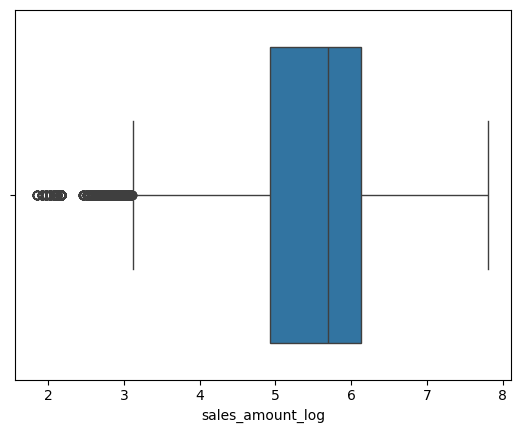

In [48]:
sns.boxplot(x=df1['sales_amount_log'])

In [49]:
df1['sales_amount_log'].skew()

np.float64(-0.6110166235995829)

Text(0.5, 1.0, 'Correlation Heatmap')

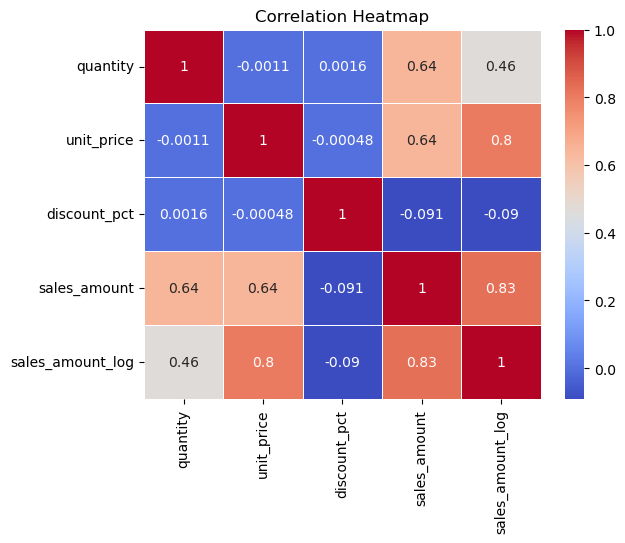

In [51]:
num_col = df1.select_dtypes(include=np.number).columns

sns.heatmap(df1[num_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

In [53]:
corr = df1[num_col].corr()['sales_amount_log'].sort_values(ascending=False)
corr

sales_amount_log    1.000000
sales_amount        0.826722
unit_price          0.803882
quantity            0.464546
discount_pct       -0.089509
Name: sales_amount_log, dtype: float64

##### 1. unit_price are highly positive correlated with sales amount log<br>2. quantity also are moderate positive correlated with sales_amount_log<br>3. discount_pct shows not correlation between sales_amount_log

In [ ]:
df1.drop(columns='product_name', inplace=True)

In [66]:
cat_col = df1.select_dtypes(include='object').columns
cat_col.shape

(8,)

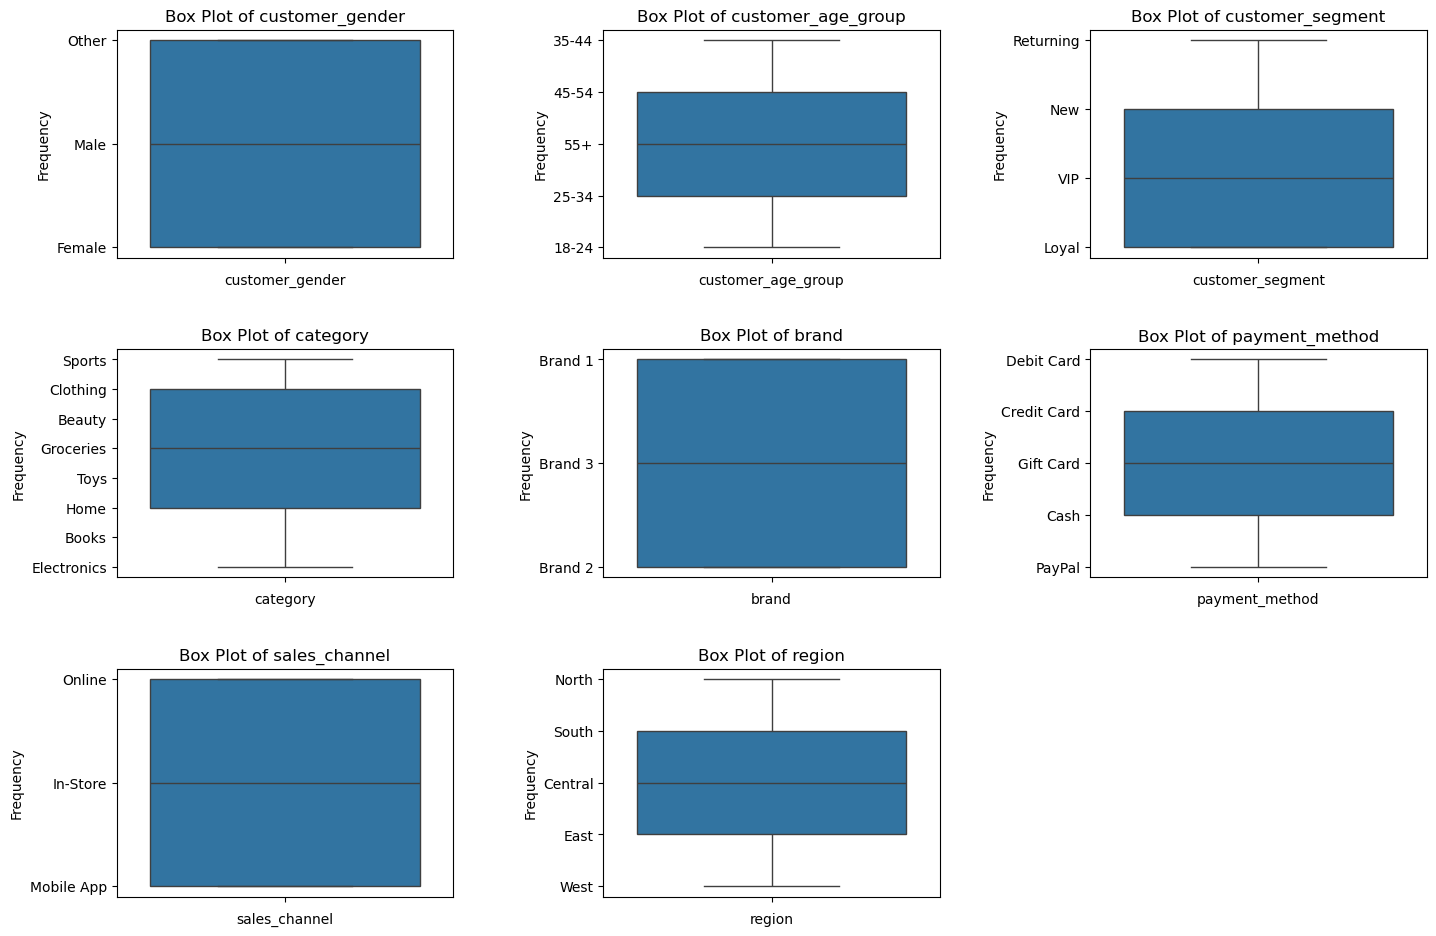

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_col,1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df1[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout(pad=3)
plt.show()

In [71]:
df1[cat_col].describe()


,customer_gender,customer_age_group,customer_segment,category,brand,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000
unique,3,5,4,8,3,5,3,5
top,Female,35-44,VIP,Sports,Brand 1,Credit Card,Mobile App,Central
freq,40268,24196,30115,15218,40240,24262,40204,24244


In [72]:
from scipy.stats import ttest_ind, f_oneway

# =========================
# TARGET VARIABLE
# =========================
target = 'sales_amount_log'

# =========================
# CATEGORICAL COLUMNS
# =========================
cat_col = [
    'customer_gender',
    'customer_age_group',
    'customer_segment',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

# =========================
# LOOP TEST
# =========================

for col in cat_col:

    n_unique = df1[col].nunique()

    print("="*70)
    print(f"Column: {col}")
    print(f"Number of Categories: {n_unique}")

    # ==================================================
    # T-TEST (2 CATEGORY)
    # ==================================================
    if n_unique == 2:

        categories = df1[col].unique()

        group1 = df1[df1[col] == categories[0]][target]
        group2 = df1[df1[col] == categories[1]][target]

        t_stat, p_value = ttest_ind(group1, group2)

        print("\nT-TEST RESULT")
        print(f"T-Statistic : {t_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")

        if p_value < 0.05:
            print("Result      : Significant Difference")
        else:
            print("Result      : No Significant Difference")

    # ==================================================
    # ANOVA (>2 CATEGORY)
    # ==================================================
    elif n_unique > 2:

        groups = [
            df1[df1[col] == category][target]
            for category in df1[col].unique()
        ]

        f_stat, p_value = f_oneway(*groups)

        print("\nANOVA RESULT")
        print(f"F-Statistic : {f_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")

        if p_value < 0.05:
            print("Result      : Significant Difference")
        else:
            print("Result      : No Significant Difference")

Column: customer_gender
Number of Categories: 3

ANOVA RESULT
F-Statistic : 1.9973
P-Value     : 0.135707
Result      : No Significant Difference
Column: customer_age_group
Number of Categories: 5

ANOVA RESULT
F-Statistic : 0.5341
P-Value     : 0.710699
Result      : No Significant Difference
Column: customer_segment
Number of Categories: 4

ANOVA RESULT
F-Statistic : 0.2514
P-Value     : 0.860420
Result      : No Significant Difference
Column: category
Number of Categories: 8

ANOVA RESULT
F-Statistic : 168.6852
P-Value     : 0.000000
Result      : Significant Difference
Column: brand
Number of Categories: 3

ANOVA RESULT
F-Statistic : 166.0471
P-Value     : 0.000000
Result      : Significant Difference
Column: payment_method
Number of Categories: 5

ANOVA RESULT
F-Statistic : 0.0845
P-Value     : 0.987232
Result      : No Significant Difference
Column: sales_channel
Number of Categories: 3

ANOVA RESULT
F-Statistic : 2.7881
P-Value     : 0.061543
Result      : No Significant Differe

In [73]:
from scipy.stats import ttest_ind, f_oneway
import numpy as np

target = 'sales_amount_log'

cat_col = [
    'customer_gender',
    'customer_age_group',
    'customer_segment',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

for col in cat_col:

    n_unique = df1[col].nunique()

    print("="*80)
    print(f"Column: {col}")
    print(f"Unique Categories: {n_unique}")

    # ==================================================
    # T-TEST + COHEN'S D
    # ==================================================
    if n_unique == 2:

        categories = df1[col].unique()

        group1 = df1[df1[col] == categories[0]][target]
        group2 = df1[df1[col] == categories[1]][target]

        # T-Test
        t_stat, p_value = ttest_ind(group1, group2)

        # Cohen's d
        mean_diff = group1.mean() - group2.mean()

        pooled_std = np.sqrt(
            (
                ((len(group1)-1) * group1.std()**2) +
                ((len(group2)-1) * group2.std()**2)
            ) / (len(group1) + len(group2) - 2)
        )

        cohens_d = mean_diff / pooled_std

        print("\nT-TEST RESULT")
        print(f"T-Statistic : {t_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")
        print(f"Cohen's d   : {cohens_d:.4f}")

        # Effect interpretation
        abs_d = abs(cohens_d)

        if abs_d < 0.2:
            effect = "Small"
        elif abs_d < 0.5:
            effect = "Medium"
        else:
            effect = "Large"

        print(f"Effect Size : {effect}")

    # ==================================================
    # ANOVA + ETA SQUARED
    # ==================================================
    elif n_unique > 2:

        groups = [
            df1[df1[col] == category][target]
            for category in df1[col].unique()
        ]

        # ANOVA
        f_stat, p_value = f_oneway(*groups)

        # Eta Squared
        grand_mean = df1[target].mean()

        ss_between = sum(
            len(group) * (group.mean() - grand_mean)**2
            for group in groups
        )

        ss_total = sum(
            (df1[target] - grand_mean)**2
        )

        eta_squared = ss_between / ss_total

        print("\nANOVA RESULT")
        print(f"F-Statistic : {f_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")
        print(f"Eta Squared : {eta_squared:.4f}")

        # Effect interpretation
        if eta_squared < 0.01:
            effect = "Small"
        elif eta_squared < 0.06:
            effect = "Medium"
        else:
            effect = "Large"

        print(f"Effect Size : {effect}")

Column: customer_gender
Unique Categories: 3

ANOVA RESULT
F-Statistic : 1.9973
P-Value     : 0.135707
Eta Squared : 0.0000
Effect Size : Small
Column: customer_age_group
Unique Categories: 5

ANOVA RESULT
F-Statistic : 0.5341
P-Value     : 0.710699
Eta Squared : 0.0000
Effect Size : Small
Column: customer_segment
Unique Categories: 4

ANOVA RESULT
F-Statistic : 0.2514
P-Value     : 0.860420
Eta Squared : 0.0000
Effect Size : Small
Column: category
Unique Categories: 8

ANOVA RESULT
F-Statistic : 168.6852
P-Value     : 0.000000
Eta Squared : 0.0097
Effect Size : Small
Column: brand
Unique Categories: 3

ANOVA RESULT
F-Statistic : 166.0471
P-Value     : 0.000000
Eta Squared : 0.0028
Effect Size : Small
Column: payment_method
Unique Categories: 5

ANOVA RESULT
F-Statistic : 0.0845
P-Value     : 0.987232
Eta Squared : 0.0000
Effect Size : Small
Column: sales_channel
Unique Categories: 3

ANOVA RESULT
F-Statistic : 2.7881
P-Value     : 0.061543
Eta Squared : 0.0000
Effect Size : Small
Colu

### Feature Selection

In [77]:
# ======================================
# Numerical Feature Selection
# ======================================

corr = df1[num_col].corr()['sales_amount_log']

corr_filtered = corr[
    (corr >= 0.3) | (corr <= -0.3)
].sort_values(ascending=False)

print(corr_filtered)


# ======================================
# Categorical Feature Selection
# ======================================

if p_value < 0.05:

    print("\nANOVA RESULT")
    print(f"F-Statistic : {f_stat:.4f}")
    print(f"P-Value     : {p_value:.6f}")
    print(f"Eta Squared : {eta_squared:.4f}")
    print(f"Effect Size : {effect}")

sales_amount_log    1.000000
sales_amount        0.826722
unit_price          0.803882
quantity            0.464546
Name: sales_amount_log, dtype: float64


#### Assign x & y value

In [79]:
x = df1[['unit_price', 'quantity', 'brand', 'category']]
y = df1['sales_amount_log']

In [88]:
x.head()

,unit_price,quantity,brand,category
0,313.53,2,Brand 1,Sports
1,366.16,1,Brand 3,Sports
2,27.99,1,Brand 3,Clothing
3,102.01,2,Brand 1,Beauty
4,259.55,1,Brand 1,Clothing


In [85]:
y

0         6.219894
1         5.905798
2         3.366951
3         5.161466
4         5.562795
            ...   
119995    4.852889
119996    5.942799
119997    6.688043
119998    7.171872
119999    5.591397
Name: sales_amount_log, Length: 120000, dtype: float64

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['brand', 'category']),
        ('scaler', StandardScaler(), ['unit_price'])
    ], remainder='passthrough'
)

In [90]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('scaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
y_pred = pipeline.predict(x_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R² Score: 0.8722
RMSE: 0.3676
MAE: 0.2762


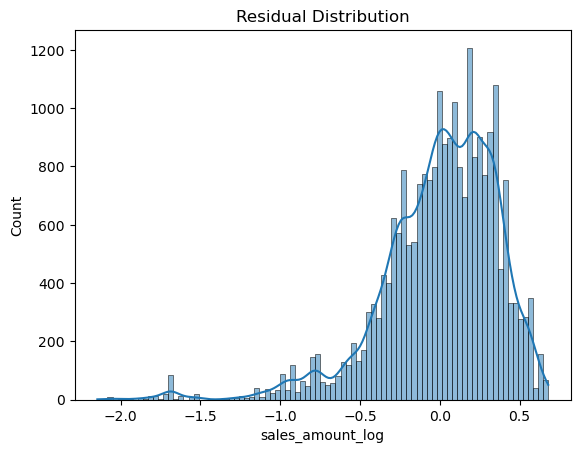

In [92]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

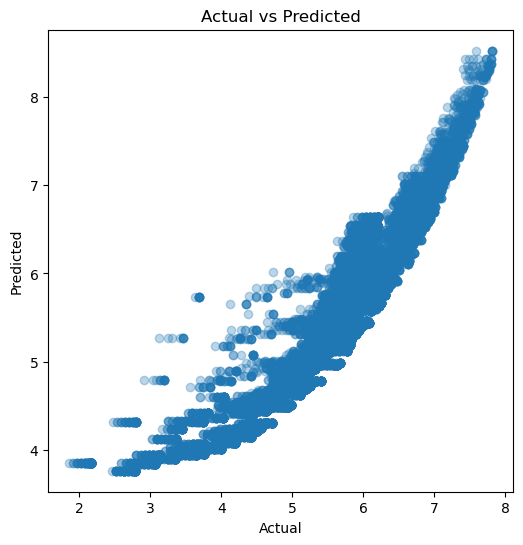

In [93]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

##### Plot shows nonlinear relationship. We need use polynomial regression

In [95]:
from sklearn.preprocessing import PolynomialFeatures

In [97]:
pipeline_poly = Pipeline([
    ('preprocessor', preprocessor),

    ('poly', PolynomialFeatures(degree=2, include_bias=False)),

    ('model', LinearRegression())
])

pipeline_poly.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('scaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [98]:
y_pred_poly = pipeline_poly.predict(x_test)

print(f"R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_poly):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.4f}")

R² Score: 0.9672
RMSE: 0.1862
MAE: 0.1384


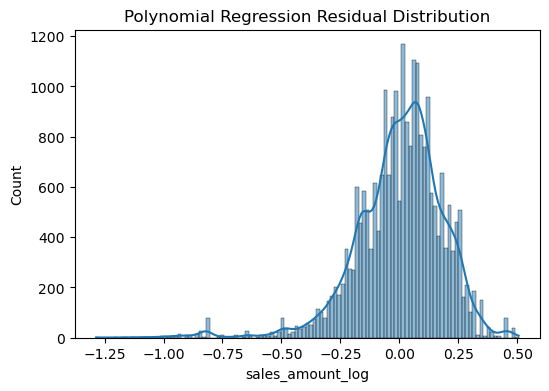

In [99]:
residuals_poly = y_test - y_pred_poly


# ======================================
# Residual Distribution
# ======================================

plt.figure(figsize=(6,4))

sns.histplot(residuals_poly, kde=True)

plt.title("Polynomial Regression Residual Distribution")

plt.show()

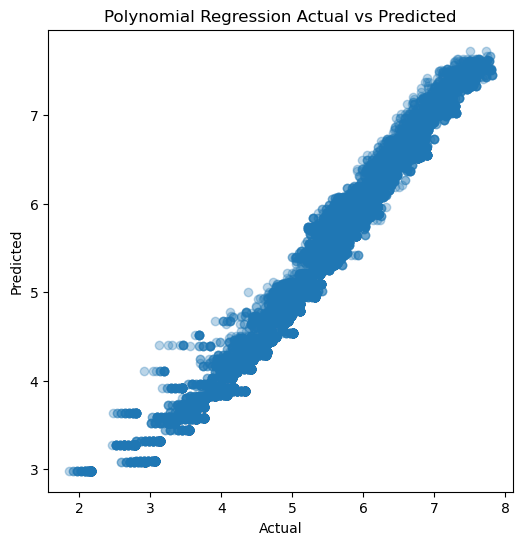

In [100]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_poly, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Polynomial Regression Actual vs Predicted")

plt.show()

In [103]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline_poly,
    x,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:")
print(cv_scores)

print(f"\nMean CV R2: {cv_scores.mean():.4f}")
print(f"Std CV R2 : {cv_scores.std():.4f}")

Cross Validation R2 Scores:
[0.96703773 0.96745286 0.96633151 0.96698706 0.96653529]

Mean CV R2: 0.9669
Std CV R2 : 0.0004


In [111]:
import joblib

joblib.dump(
    pipeline_poly,
    'sales_prediction_model_poly.pkl'
)

['sales_prediction_model_poly.pkl']

In [113]:
loaded_model = joblib.load(
    'sales_prediction_model_poly.pkl'
)

In [114]:
new_data = pd.DataFrame({
    'unit_price': [300],
    'quantity': [2],
    'brand': ['Brand 1'],
    'category': ['Sports']
})

pred_log = loaded_model.predict(new_data)

pred_actual = np.expm1(pred_log)

print(pred_actual)

[594.89997012]


### Another Model